In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from dotenv import load_dotenv

# Настройки для красивых графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Функция для загрузки данных из БД в Pandas DataFrame
def fetch_data(query):
    load_dotenv('.env') # Подгружаем переменные окружения
    
    # Для визуализации (с локального ПК) подключаемся по порту 5433
    conn = psycopg2.connect(
        host='localhost',
        port='5433', 
        database=os.getenv("DB_NAME"),
        user=os.getenv("DB_USER"),
        password=os.getenv("DB_PASSWORD")
    )
    
    # pandas умеет сам выполнять SQL-запросы и превращать их в DataFrame
    df = pd.read_sql_query(query, conn)
    conn.close()
    return df

print("Подключение настроено успешно!")

Подключение настроено успешно!


# Топ 10 владельцев по суммее штрафа

C:\Users\Ivan\AppData\Local\Temp\ipykernel_22440\1688896365.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)
C:\Users\Ivan\AppData\Local\Temp\ipykernel_22440\3258517584.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_top_owners, x='Сумма штрафов', y='Владелец', palette='Reds_r')


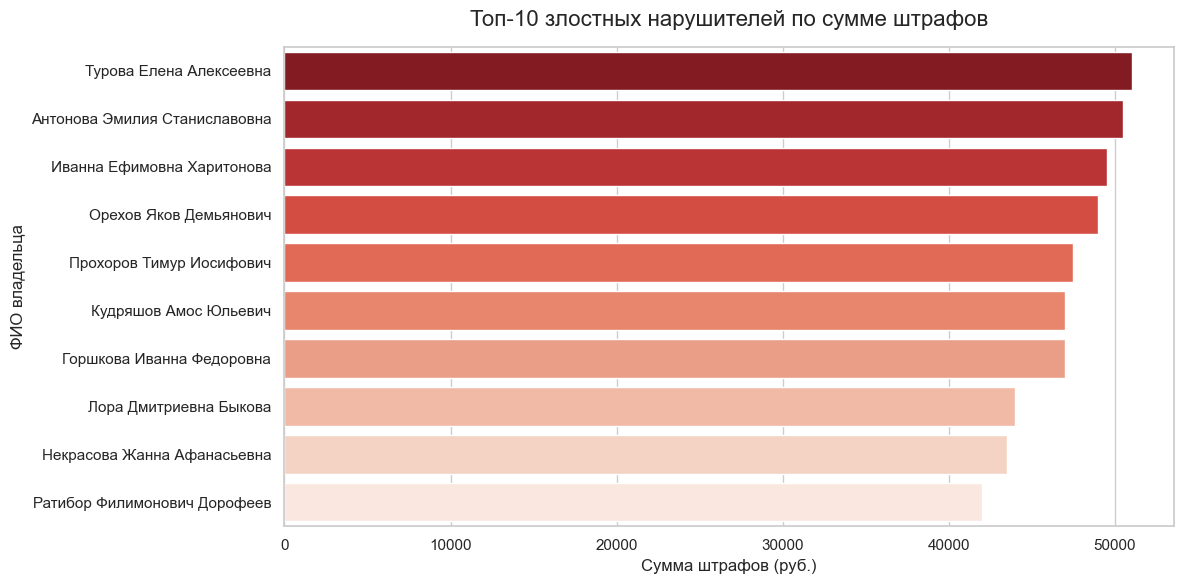

In [3]:
#SQL-запрос: Джоиним 3 таблицы, группируем по ФИО, считаем сумму штрафов
query_top_owners = """
    SELECT o.name AS "Владелец", SUM(f.amount) AS "Сумма штрафов"
    FROM fines f
    JOIN cars c ON f.car_id = c.car_id
    JOIN car_owners o ON c.owner_id = o.owner_id
    GROUP BY o.name
    ORDER BY "Сумма штрафов" DESC
    LIMIT 10;
"""

df_top_owners = fetch_data(query_top_owners)

plt.figure(figsize=(12, 6))
sns.barplot(data=df_top_owners, x='Сумма штрафов', y='Владелец', palette='Reds_r')
plt.title('Топ-10 злостных нарушителей по сумме штрафов', fontsize=16, pad=15)
plt.xlabel('Сумма штрафов (руб.)', fontsize=12)
plt.ylabel('ФИО владельца', fontsize=12)
plt.tight_layout()
plt.show()

# Динамика штрафов по месяцам

C:\Users\Ivan\AppData\Local\Temp\ipykernel_22440\1688896365.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


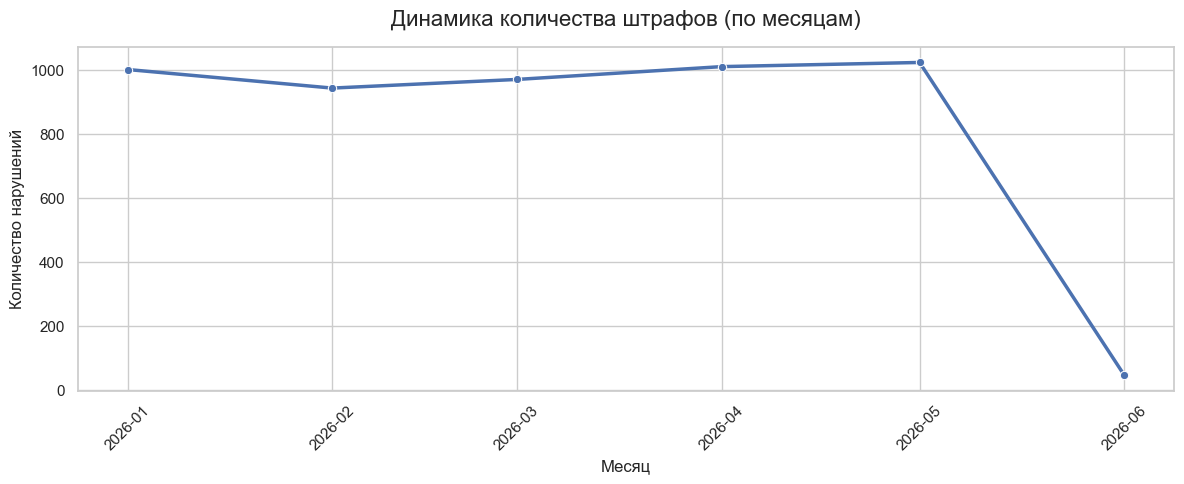

In [4]:
# Усекаем дату до месяца и считаем количество штрафов
query_dynamics = """
    SELECT DATE_TRUNC('month', date)::date AS "Месяц", COUNT(fine_id) AS "Количество штрафов"
    FROM fines
    GROUP BY DATE_TRUNC('month', date)
    ORDER BY "Месяц";
"""

df_dynamics = fetch_data(query_dynamics)
# Конвертируем колонку в формат datetime для красивого отображения на оси
df_dynamics['Месяц'] = pd.to_datetime(df_dynamics['Месяц'])

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_dynamics, x='Месяц', y='Количество штрафов', marker='o', color='b', linewidth=2.5)
plt.title('Динамика количества штрафов (по месяцам)', fontsize=16, pad=15)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Количество нарушений', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Круговая диаграмма статей нарушений

C:\Users\Ivan\AppData\Local\Temp\ipykernel_22440\1688896365.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


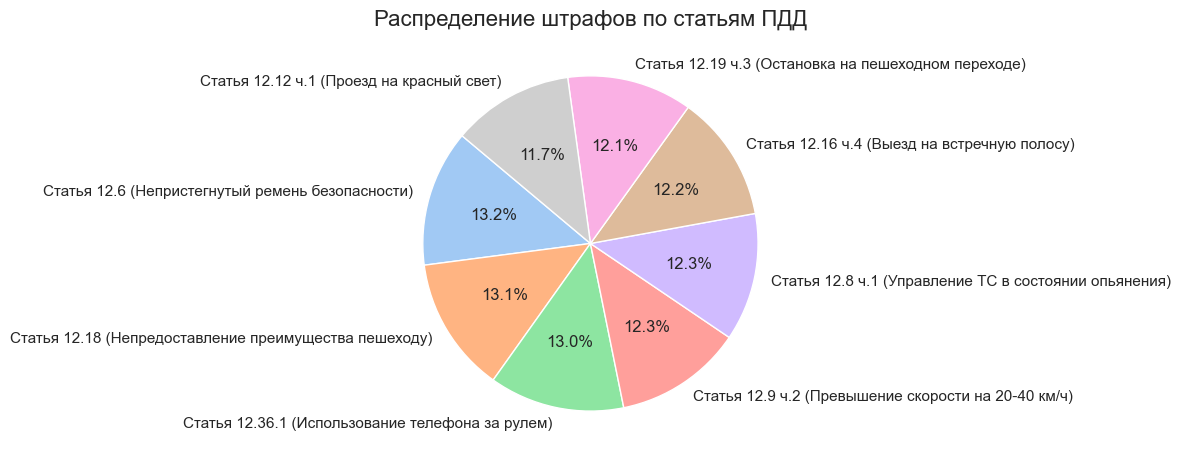

In [6]:
# Забираем данные из нашей готовой витрины
query_articles = "SELECT article AS \"Статья\", total_fines AS \"Количество\" FROM dmr.fine_stats;"
df_articles = fetch_data(query_articles)

# Так как статей может быть много, для красивого Pie-чарта возьмем топ-5, 
# а остальные сгруппируем в "Другие" (если их больше 5)
df_articles = df_articles.sort_values(by='Количество', ascending=False)

plt.figure(figsize=(10, 8))
colors = sns.color_palette('pastel')[0:len(df_articles)]
plt.pie(
    df_articles['Количество'], 
    labels=df_articles['Статья'], 
    colors=colors, 
    autopct='%1.1f%%', # Показывать проценты
    startangle=140, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
plt.title('Распределение штрафов по статьям ПДД', fontsize=16)
plt.tight_layout()
plt.show()

# Доля оплаченных штрафов (Donut chart / Пончик)

C:\Users\Ivan\AppData\Local\Temp\ipykernel_22440\1688896365.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


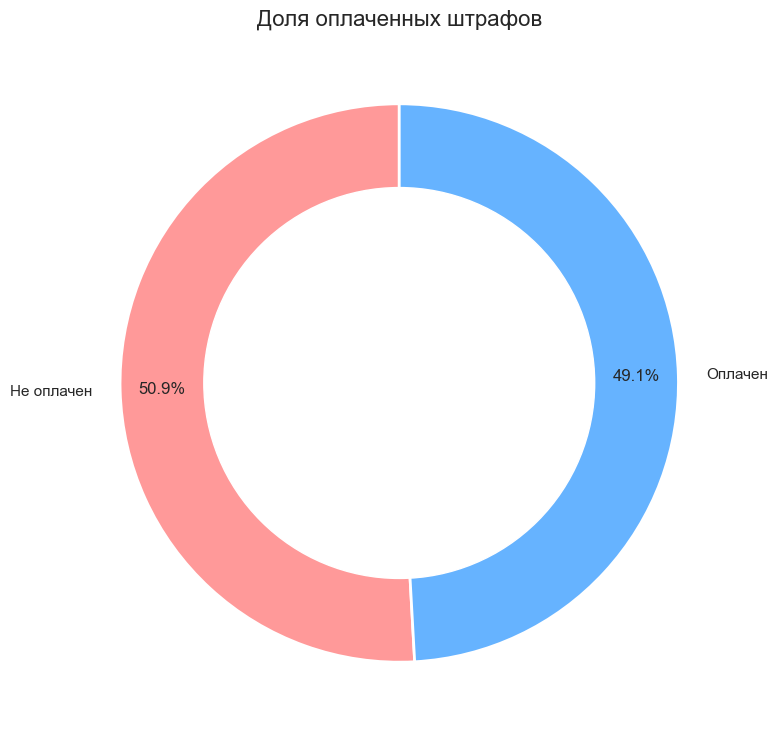

In [7]:
# Простая группировка по статусу из таблицы fines
query_status = """
    SELECT status AS "Статус", COUNT(*) AS "Количество"
    FROM fines
    GROUP BY status;
"""

df_status = fetch_data(query_status)

plt.figure(figsize=(8, 8))
# Настройка цветов: зеленый для оплаченных, красный для неоплаченных
colors = ['#ff9999' if s == 'Не оплачен' else '#66b3ff' for s in df_status['Статус']]

# Рисуем круговую диаграмму
plt.pie(
    df_status['Количество'], 
    labels=df_status['Статус'], 
    colors=colors, 
    autopct='%1.1f%%', 
    startangle=90, 
    pctdistance=0.85,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Рисуем белый круг в центре, чтобы получился график-"пончик" (Donut Chart)
centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title('Доля оплаченных штрафов', fontsize=16)
plt.tight_layout()
plt.show()